# Pseudohuérfanas: construcción y recuperación del blanco

Construcción de las **k = 1** (drogas con exactamente un blanco proteico conocido
en una especie), su estratificación en grupos 0–3, el `frank` por especie y la
clasificación de la semilla en *nula / no informativa / informativa*.

Cada droga se **orfaniza**: se le sacan todas sus aristas de bioactividad y se
arma la semilla sólo con su vecindario químico. El blanco verdadero puede volver
por otra droga vecina —eso es inferencia directa y es legítima—, nunca por sí
misma (`comun/tests/test_fuga.py`).

Los parámetros son los óptimos por especie de `genome_prioritization/02`, y la
capa química va **filtrada por promiscuidad** (CONVENCIONES.md §10): estos números no son
comparables con los de la versión v3 (fuera de este repositorio).

Origen: el análisis de huérfanas de la versión v3 (fuera de este repositorio).
Salidas: `01_<especie>_pseudohuerfanas.csv`, `01_k1_drugs.csv`, `01_resumen_frank.csv`.

## Imports

In [1]:
import sys, os
for _v in ("OMP_NUM_THREADS", "OPENBLAS_NUM_THREADS", "MKL_NUM_THREADS", "NUMEXPR_NUM_THREADS"):
    os.environ.setdefault(_v, "1")          # antes de numpy: un hilo por proceso

import numpy as np, pandas as pd
import matplotlib.pyplot as plt, seaborn as sns

from pathlib import Path
# raiz del repositorio: se busca hacia arriba la carpeta que tiene DB/,
# asi el notebook corre desde donde sea que se haya clonado
RAIZ = Path.cwd()
while not (RAIZ / "DB").is_dir() and RAIZ != RAIZ.parent:
    RAIZ = RAIZ.parent
sys.path.insert(0, str(RAIZ / "comun"))
sys.path.insert(0, str(RAIZ / "huerfanas"))
%load_ext autoreload
%autoreload 2
import tdr, nucleo as nf
import funciones_huerfanas as fh              # el .py de esta carpeta
import figuras as F                        # comun/figuras.py: las figuras, desde las tablas

SALIDAS = tdr.out("huerfanas")
FIGURAS = SALIDAS / "figuras"
NB      = "01"                             # numero de este notebook: prefija todo lo que genere
n_core  = tdr.N_CORE_DEFAULT                # 20 salvo TDR_NCORE

plt = tdr.estilo()
SALIDAS

PosixPath('/data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/huerfanas_out')

## Datos

In [2]:
# cluster_consistent=True: `huerfanas/` filtra los positivos/negativos
# inconsistentes a nivel cluster, como en la versión v3.
crudo = tdr.cargar_db(anotaciones=True, quimica=True, cluster_consistent=True)

# CONVENCIONES.md §10: el filtro de promiscuidad se APLICA antes de armar ninguna semilla.
# La lista sale de analiceDB/03; si falta, el error dice qué correr.
promiscuos = tdr.compuestos_promiscuos()
datos = tdr.filtrar_capa_quimica(crudo, promiscuos)

optimos = fh.parametros_optimos()          # de genome_prioritization_out/02_*
len(datos.posdt), len(optimos)

· 00_specie_target


· 03_bioactivities_target_compound


· 04a_interpro / 04b_orthomcl


· 01/02 clusters y aristas quimicas (pesado)


filtro de promiscuidad (MW < 150 y N_parentales > 100): 5 compuestos


  sclus 831175 -> 831170 (0.00 % removido)


  dds   440 -> 440 (0.00 % removido)


(248457, 16)

## Acondicionamiento

In [3]:
k1, posdt_sp = fh.construir_pseudohuerfanas(datos)
especies = [sp for sp in k1["sp_id"].value_counts().index if sp in optimos]
muestras = {sp: fh.muestra_pseudohuerfanas(k1[k1["sp_id"] == sp], n=fh.N_MUESTRA)
            for sp in especies}

print(f"{len(especies)} especies con pseudohuérfanas y parámetros óptimos")


pseudohuerfanas: 60253 drogas, 26 especies, grupos {0: 22375, 1: 17306, 2: 9830, 3: 10742}


16 especies con pseudohuérfanas y parámetros óptimos


## Corrida

In [4]:
# celda de corrida: el ciclo se lee aca
import time
k1.to_csv(SALIDAS / f"{NB}_k1_drugs.csv", index=False)
for sp in especies:
    t0  = time.time()
    ctx = fh.preparar_especie(datos, sp, optimos[sp], k1)         # RS con sus optimos
    fh.fijar_contexto(datos, posdt_sp, ctx)                       # visible por fork
    filas = fh.paralelizar(fh.priorizar_droga, muestras[sp]["drug_id"], n_core=n_core, desc=sp)
    fh.guardar_huerfanas(filas, SALIDAS, NB, sp)                  # -> 01_<sp>_pseudohuerfanas.csv
    print(f"  {sp} en {time.time() - t0:.0f} s", flush=True)

# el resumen por grupo / semilla / especie: la metrica de cada iteracion
res = fh.cargar_resultados(SALIDAS, NB, patron="*_pseudohuerfanas")
res = res.merge(k1[["drug_id", "sp_id", "grupo"]].rename(columns={"sp_id": "especie"}),
                on=["drug_id", "especie"], how="left")
fh.resumen_frank(res).to_csv(SALIDAS / f"{NB}_resumen_frank.csv", index=False)

fh.escribir_meta(SALIDAS, NB, notebook="01_pseudohuerfanas.ipynb",
                 params={"optimos": optimos, "n_muestra": fh.N_MUESTRA, "rseed": fh.RSEED},
                 n_core=n_core, especies=especies,
                 filtro_promiscuidad=True, n_promiscuos=len(promiscuos))

[3] 1000 tareas en 20 procesos


  3: 100/1000


  3: 200/1000


  3: 300/1000


  3: 400/1000


...

  5: 36/38


  5: 38 drogas -> 01_5_pseudohuerfanas.csv  (frank<0.1 en 26.3%, semilla {'nula': 20, 'informativa': 10, 'no informativa': 8})


  5 en 12 s


  meta -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/huerfanas_out/01_meta.json


{'notebook': '01_pseudohuerfanas.ipynb',
 'nb': '01',
 'fecha': '2026-09-24 16:11',
 'params': {'optimos': {'0': [1.2, 1.0, None, 0.8],
   '1': [1.2, 1.0, 1.0, 0.8],
   '3': [0.0, 0.5, 1.0, 0.8],
   '4': [0.0, 1.0, 1.0, 0.8],
   '5': [0.3, 0.5, 0.5, 0.8],
   '9': [0.3, 1.5, 1.0, 0.8],
   '10': [0.9, 0.0, 0.0, 0.8],
   '15': [0.3, 1.5, None, 0.8],
   '17': [0.0, 1.0, 1.0, 0.8],
   '18': [0.3, 1.0, None, 0.8],
   '21': [0.0, 1.0, 0.5, 0.8],
   '22': [0.0, 1.0, 1.0, 0.8],
   '23': [0.0, 1.5, 0.5, 0.8],
   '25': [1.2, 1.0, 0.5, 0.8],
   '26': [1.2, 1.0, 1.0, 0.8],
   '28': [1.2, 1.0, 0.5, 0.8]},
  'n_muestra': 1000,
  'rseed': 123457},
 'n_core': 20,
 'tablas_db': {'00_specie_target.csv': '2026-09-08',
  '01_clusters_fingerprint.csv': '2026-09-08',
  '01_edges_clusters_fingerprint.part00.csv.gz': '2026-09-08',
  '01_edges_clusters_fingerprint.part01.csv.gz': '2026-09-08',
  '02_clusters_subestructure.csv': '2026-09-08',
  '02_edges_clusters_subestructure.csv': '2026-09-08',
  '03_bioactivi

# Resultados

Desde acá no se toca la base: cada figura lee sus tablas de `resultados/` y la
dibuja `F.dibujar(...)` (las funciones están en `figuras_huerfanas.py`). Para
regenerarlas sin volver a pagar la corrida alcanza con la celda de imports y esta
sección, o, desde la raíz del repositorio:

    python comun/figuras.py huerfanas

In [5]:
resumen = pd.read_csv(SALIDAS / f"{NB}_resumen_frank.csv")
resumen[resumen["particion"].isin(["total", "semilla", "grupo"])].round(1)

,corte,particion,valor,n,pct_recuperadas,pct_sin_semilla
0,0.1,total,todas,7782,17.5,67.8
1,0.1,grupo,0,2614,0.8,98.7
2,0.1,grupo,1,1450,34.6,47.0
3,0.1,grupo,2,2098,6.1,84.1
4,0.1,grupo,3,1620,43.8,15.2
5,0.1,semilla,informativa,1365,99.6,0.0
6,0.1,semilla,no informativa,1144,0.0,0.0
7,0.1,semilla,nula,5273,0.0,100.0


  figura -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/huerfanas_out/figuras/01_f01_grupos_por_especie.pdf


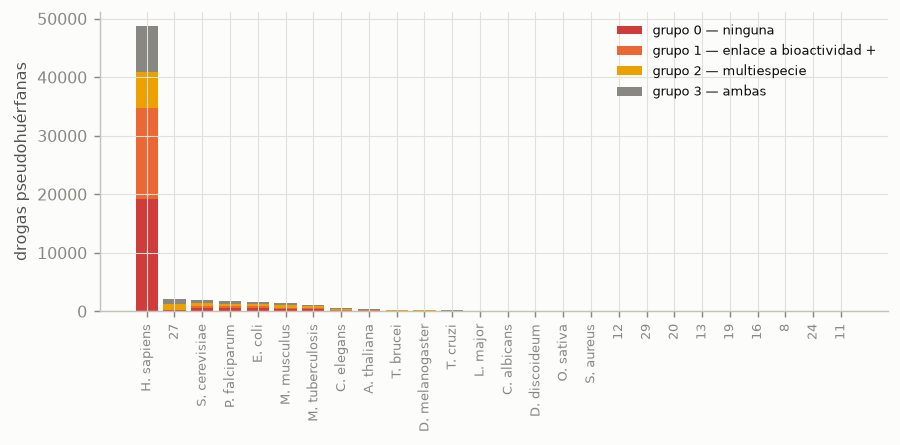

In [6]:
F.dibujar("01_f01_grupos_por_especie");

  figura -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/huerfanas_out/figuras/01_f02_frank_por_grupo.pdf


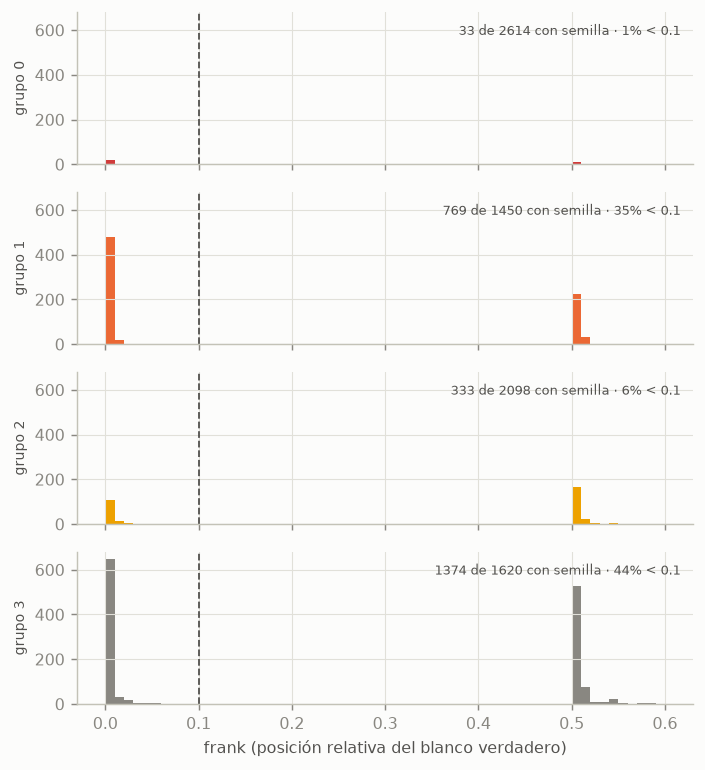

In [7]:
F.dibujar("01_f02_frank_por_grupo");

  figura -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/huerfanas_out/figuras/01_f03_semilla_por_especie.pdf


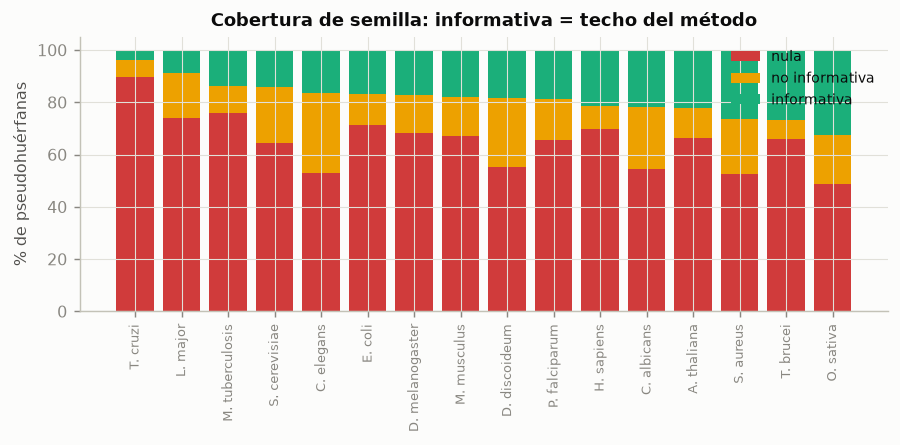

In [8]:
# El cuello de botella: la clase de semilla, no la reponderación
F.dibujar("01_f03_semilla_por_especie");

  figura -> /data1/TDR-2025/TDR_v7/GW-AI-course/TDR-GW-AI-course/resultados/huerfanas_out/figuras/01_f04_recuperacion_por_semilla.pdf


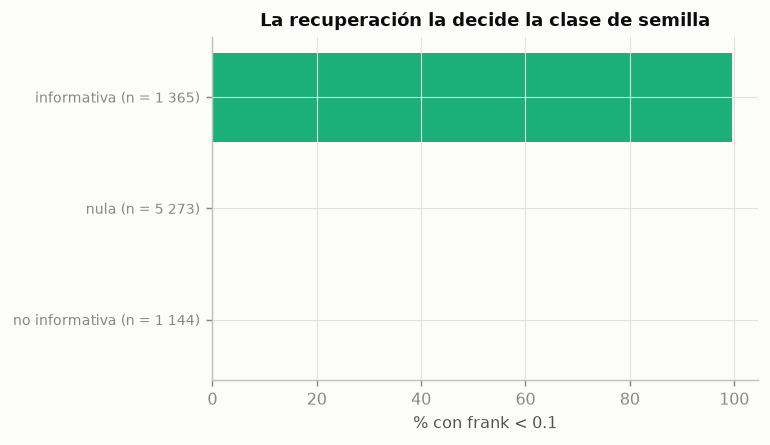

In [9]:
F.dibujar("01_f04_recuperacion_por_semilla");